# Quick Review of Gradient Descent

<a href="https://colab.research.google.com/github/HassanAlgoz/dl/blob/main/modules/M2/01-gradient-descent-walkthrough/01-gradient-descent-walkthrough.ipynb" target="_blank">
  <img src="https://raw.githubusercontent.com/HassanAlgoz/dl/main/assets/Open%20in%20Colab-F9AB00.svg" alt="Open in Colab" height="50"/>
</a>


In [1]:
# --- Setup: Clone repo & cd into correct folder (for lab setup convenience) ---
import os
import subprocess

repo_url = "https://github.com/HassanAlgoz/dl.git"
lab_folder = "dl/modules/M2/01-gradient-descent-walkthrough"

# Only clone if the folder doesn't exist
if not os.path.exists(lab_folder):
    subprocess.run(["git", "clone", repo_url])

# Change working directory to the lab folder
os.chdir(lab_folder)


### What is it?

If you want to oversimplify machine learning, you can boil it down to everything being an optimization problem. What are we optimizing? Think back to Linear Regression and the Mean Squared Error (MSE). MSE measures how “bad” our predictions are by squaring the residuals, summing them, and dividing by the total number of samples. MSE is a loss function — a function that tells us how wrong our model is.

When we call `.fit()` on many machine learning models, the model tries to minimize its loss function. Gradient descent is one of the most common algorithms used to perform this minimization.

### Why do we need it?

If you’ve taken calculus, you might remember finding minima by taking the derivative and setting it to zero.

Example:


If `f(x) = x²` then `f′(x) = 2x`, and setting `2x = 0` gives a minimum at `x = 0`.


So why gradient descent? Most real loss functions — especially in neural networks — don’t have a simple closed-form solution. We can’t just take a derivative and solve for zero.

Gradient descent solves this by taking small steps downhill on the loss curve. At each step, it:

* Computes the slope (gradient),

* Moves in the opposite direction of the slope,

* Scales the size of the step using the learning rate (usually written as α),

* Repeats until the slope is essentially zero.

* This iterative procedure is how neural networks — and many other ML models — learn.

---

### Sidenote

Remember regularized models like Lasso and Ridge? Sometimes you get a `ConvergenceWarning`. That’s sklearn telling you the iterative optimization algorithm (often coordinate descent or another solver) didn’t converge within the allowed number of iterations.

---

## Simple Example with Python!

In [ ]:
# %pip install -qqq numpy matplotlib

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Define our function and derivative from example above
def f(x):
  return x**2

def f_deriv(x):
  return 2*x

In [11]:
# Setting up gradient descent

alpha = 0.1 # our learning rate, think how big of a step we're going down our loss function

w = 5 # random starting point on our loss function curve

num_steps = 25 # in some algorithms, we set how many iterations or steps of gradient descent

history = [w] # we'll use this to plot later on

In [12]:
# Let's run gradient descent!
for _ in range(num_steps):
  grad = f_deriv(w)
  w = w - alpha * grad # update our x position by size alpha times the gradient
  history.append(w)

In [14]:
xs = np.linspace(-5, 5, 200) # generate some x values
ys = f(xs)
print(type(xs), type(ys))
# Also converting history to an np.array, throws a type error if not an array
history = np.array(history)

<class 'numpy.ndarray'> <class 'numpy.ndarray'>


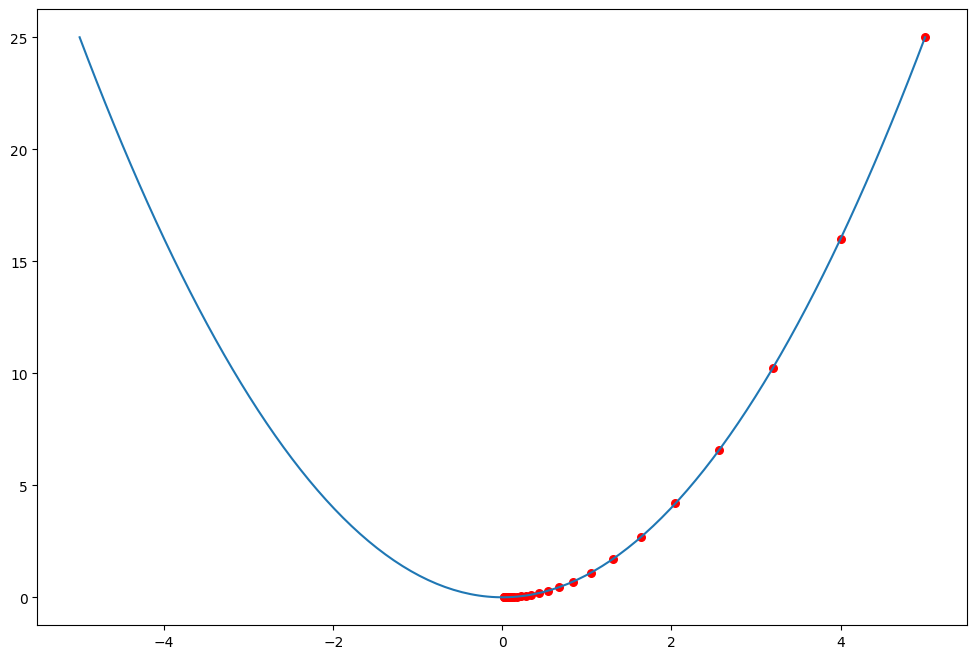

In [10]:
# Plot gradient descent
plt.figure(figsize=(12,8))
plt.plot(xs, ys, label="f(x) = x**2")
plt.scatter(history, f(history), color='red', s=30, label='Gradient Descent')
# plt.plot(history, f(history), color='green', alpha=0.5)

In [ ]:
# # Can copy/paste the below code to annotate the first and last points of gradient descent history
# plt.scatter(history[0], f(history[0]), label='start')
# plt.scatter(history[-1], f(history[-1]), label='start')